## Seepage vs Δh Model Comparison


This notebook compares two models for seepage as a function of the water-level difference between estuary and ocean Δh, using an effective berm conductance $K$.

We model seepage as:

$$
S \;=\; K(\Delta h)\,\Delta h,
$$
where $(K(\Delta h))$ is an *effective berm conductance*. We compare two alternative models for $(K(\Delta h))$:

- **Constant $(K)$ (linear fit):**
$$
K(\Delta h) \;=\; K 
\quad\Rightarrow\quad
S \;=\; K \cdot \Delta h
$$

- **Offset–power $(K)$ :**
$$
K(\Delta h) \;=\; K \cdot(\Delta h+\text{offset})^{b}
\quad\Rightarrow\quad
S \;=\; K \cdot (\Delta h+\text{offset})^{b} \cdot \Delta h
$$

Here, offset represents an effective $\Delta h$ threshold for flow.


### Model-comparison approaches
1. *Pooled fit*: one parameter set fit to all closure events.  
2. *Per-event fits:* parameters estimated separately within each event; results summarized across events.

### Evaluation
- *Information criteria:* *sum* event-level AIC/BIC for per-event fits (equivalently, sum $(-2\log L$) and add penalties).  
- *Goodness of fit:* report R^2 and RMSE; provide unweighted and duration-weighted summaries across events.


Preliminary 
seepage really strong,
two models
linear model.
based on idea the flow path cross section area doesn't change much with water level
following same pipe eachn time 
depends linearly on h
convenient for management purposes

other model - quadratic, homogeneous sand barrier, gravel, flow cross sectional area should increase with rising water level, dependence close to quadratic, w value flow length doesn't change much with water level
how deep the flow path, whether to compare estuary to mean sea level / mean low tide level.
doesn't seem to matter all that much, general model.

 

In [42]:
# --- Imports & configuration ---
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.optimize import minimize
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 300,
    "figure.figsize": (8, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
})

def r2_centered(y: np.ndarray, yhat: np.ndarray) -> float:
    """Centered R² = 1 − SSE/SST, where SST is around ȳ (fits are through origin)."""
    sse = np.sum((y - yhat)**2)
    sst = np.sum((y - y.mean())**2)
    return 1 - sse/sst if sst > 0 else np.nan

def aic_gaussian(sse: float, n: int, k: int) -> float:
    """AIC for least squares under Gaussian errors: AIC = n·ln(SSE/n) + 2k (lower is better)."""
    return n * np.log(sse / n) + 2 * k

def bic_gaussian(sse: float, n: int, k: int) -> float:
    """BIC for least squares under Gaussian errors: BIC = n·ln(SSE/n) + k·ln(n) (lower is better)."""
    return n * np.log(sse / n) + k * np.log(n)

# Models (through origin)
def model_linear(params: np.ndarray, x: np.ndarray) -> np.ndarray:
    """Linear through origin: S = K · Δh."""
    K = params[0]
    return K * x

def model_power_offset(params: np.ndarray, x: np.ndarray) -> np.ndarray:
    """Offset–power through origin: S = K · Δh · (Δh + offset)^b.
    Note: requires Δh + offset ≥ 0 for non-integer b; enforce upstream if needed."""
    K, offset, b = params
    print(median_delta_h)
    return K * x * (((x + offset))/median_delta_h)**b

def sse_linear(params: np.ndarray, x: np.ndarray, y: np.ndarray) -> float:
    """Sum of squared errors for the linear model."""
    return np.sum((y - model_linear(params, x))**2)

def sse_power_offset(params: np.ndarray, x: np.ndarray, y: np.ndarray) -> float:
    """Sum of squared errors for the offset–power model."""
    return np.sum((y - model_power_offset(params, x))**2)

import numpy as np

# --- helpers ---------------------------------------------------------------
def _unpack_x(x):
    """
    Accept either:
      - x: np.ndarray of Δh               (existing models)
      - x: (delta_h, visitor_h) tuple     (new model)
    Returns (delta_h, visitor_h_or_None)
    """
    if isinstance(x, (tuple, list)) and len(x) == 2:
        dh, vh = x
        return np.asarray(dh), np.asarray(vh)
    return np.asarray(x), None

# --- existing models (unchanged) -------------------------------------------
def model_linear(params: np.ndarray, x: np.ndarray) -> np.ndarray:
    """Linear through origin: S = K · Δh."""
    K = float(params[0])
    dh, _ = _unpack_x(x)
    return K * dh

def model_power_offset(params: np.ndarray, x: np.ndarray) -> np.ndarray:
    """Offset–power through origin: S = K · Δh · ((Δh + offset)/median_Δh)^b.
    Note: requires Δh + offset ≥ 0 for non-integer b; enforce upstream if needed."""
    K, offset, b = params
    dh, _ = _unpack_x(x)
    # Safe median scale (avoid /0 and keep units tidy)
    med_dh = np.nanmedian(dh) if np.isfinite(np.nanmedian(dh)) and np.nanmedian(dh) != 0 else 1.0
    return K * dh * ((dh + offset) / med_dh) ** b

LAMBDA_OFF = 1e-2  # tune 1e-4–1e-1
def sse_power_offset_ridge(params, x, y):
    K, off, b = params
    resid = y - model_power_offset(params, x)
    pen = LAMBDA_OFF * (off**2)
    return np.sum(resid**2) + pen
# then pass sse_power_offset_ridge to minimize(...)


def sse_linear(params: np.ndarray, x: np.ndarray, y: np.ndarray) -> float:
    return np.sum((y - model_linear(params, x))**2)

def sse_power_offset(params: np.ndarray, x: np.ndarray, y: np.ndarray) -> float:
    return np.sum((y - model_power_offset(params, x))**2)

# --- NEW third model --------------------------------------------------------
def model_visitor_power_offset(params: np.ndarray, x) -> np.ndarray:
    """
    Third option:
        S = K · Δh · ((visitor_h + offset)/median_visitor_h)^b

    x should be a tuple: (delta_h, visitor_h).
    For safety, if visitor_h + offset < 0 anywhere (non-integer b), the caller's SSE
    should penalize those params (we do that in the SSE).
    """
    K, offset, b = params
    dh, vh = _unpack_x(x)
    if vh is None:
        raise ValueError("model_visitor_power_offset expects x=(delta_h, visitor_h).")

    med_vh = np.nanmedian(vh)
    if not np.isfinite(med_vh) or med_vh == 0:
        med_vh = 1.0  # conservative fallback to avoid /0

    return K * dh * ((vh + offset) / med_vh) ** b

def sse_visitor_power_offset(params: np.ndarray, x, y: np.ndarray) -> float:
    """
    SSE for the visitor_h-powered model.
    Enforces (visitor_h + offset) >= 0 by returning +inf if violated.
    """
    _, vh = _unpack_x(x)
    if vh is None:
        return np.inf

    K, offset, b = params
    # Hard guard to keep fractional powers real-valued
    if np.any((vh + offset) < 0):
        return np.inf

    yhat = model_visitor_power_offset(params, x)
    # If any NaNs/Infs appear, penalize strongly
    if not np.all(np.isfinite(yhat)):
        return np.inf

    return np.sum((y - yhat) ** 2)




## Load daily data
- Parse `delta_h` and `seepage` as numeric.
- Drop NA; enforce `delta_h > 0` (for power terms).


In [43]:
from pathlib import Path
import pandas as pd

# Path to the pooled, event-labeled panel saved as CSV
data_path = Path("../data/processed/pooled_event_df.csv")

# Load the data
pooled_event_df = pd.read_csv(data_path)

# Ensure numeric types; coerce bad parses to NaN (so they can be dropped)
pooled_event_df["delta_h"] = pd.to_numeric(pooled_event_df["delta_h"], errors="coerce")
pooled_event_df["seepage"] = pd.to_numeric(pooled_event_df["seepage"], errors="coerce")

# Drop rows missing either key variable
pooled_event_df = pooled_event_df.dropna(subset=["delta_h", "seepage"])

# Quick peek at the core columns
display(pooled_event_df[["delta_h", "seepage", "event"]].head())


# add row-count per event to the original DataFrame
pooled_event_df["n"] = pooled_event_df.groupby("event")["event"].transform("size").astype("int64")
pooled_event_df = pooled_event_df.query("n>5")

# Row count after cleaning (i.e., number of event-days retained)
print(f"Closure days with data: {len(pooled_event_df)}")

median_delta_h = pooled_event_df['delta_h'].median()
min_delta_h = pooled_event_df['delta_h'].min()


,delta_h,seepage,event
0,0.728999,0.240583,0
1,0.803515,0.887796,0
2,0.906064,0.896792,0
3,0.966680,0.867753,0
4,1.036316,0.819474,0


Closure days with data: 404


In [44]:
# --- Imports & I/O ---
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.optimize import minimize_scalar

# Path to the pooled, event-labeled panel saved as CSV
data_path = Path("../data/processed/pooled_event_df.csv")

# Load the data
pooled_event_df = pd.read_csv(data_path)

# Ensure numeric types; coerce bad parses to NaN (so they can be dropped)
pooled_event_df["delta_h"] = pd.to_numeric(pooled_event_df["delta_h"], errors="coerce")
pooled_event_df["seepage"] = pd.to_numeric(pooled_event_df["seepage"], errors="coerce")

# Drop rows missing either key variable
pooled_event_df = pooled_event_df.dropna(subset=["delta_h", "seepage"])

# Quick peek at the core columns
display(pooled_event_df[["delta_h", "seepage", "event"]].head())

# add row-count per event to the original DataFrame
pooled_event_df["n"] = pooled_event_df.groupby("event")["event"].transform("size").astype("int64")
pooled_event_df = pooled_event_df.query("n>=5")

# Row count after cleaning (i.e., number of event-days retained)
print(f"Closure days with data: {len(pooled_event_df)}")

median_delta_h = pooled_event_df['delta_h'].median()
min_delta_h = pooled_event_df['delta_h'].min()

# =============================================================================
#                                CONFIG
# =============================================================================
thresholds = [5, 6, 7, 8, 10, 12, 15]

# Regularization on offset (L2 toward off0)
LAM_OFF = 0.5     # adjust 0.5–10 for more/less shrinkage
OFF0    = 0.0     # prior target for offset (meters)

# Optional: equal-weight by event (each event contributes ~1 total weight)
EVENT_EQUAL_WEIGHTING = False

EPS = 1e-12

# =============================================================================
#                        GLOBAL OFFSET BOUNDS (ONCE)
# =============================================================================
x_global = pooled_event_df["delta_h"].to_numpy(float)
# Lower bound so (Δh + offset) > 0 for all observed Δh
offset_lb_global = -float(np.nanmin(x_global)) + 1e-9

# Upper bound: small fraction of robust Δh range + site prior cap (meters)
q05, q95 = np.nanquantile(x_global, [0.05, 0.95])
R = float(q95 - q05)
site_cap = 0.30           # meters; tighten if your site warrants it
offset_ub_global = min(0.30 * R, site_cap)

# Ensure the interval has positive width
if offset_ub_global <= offset_lb_global + 1e-6:
    offset_ub_global = offset_lb_global + max(0.05 * R, 0.05)

print(f"Global offset bounds: [{offset_lb_global:.4g}, {offset_ub_global:.4g}] m")

# =============================================================================
#                         HELPERS: MODELS & METRICS
# =============================================================================
def model_linear(K, x):
    return K * x

def model_power_offset(K, off, b, x):
    return K * x * np.power(x + off, b)

def r2_centered(y, yhat):
    y = np.asarray(y, float); yhat = np.asarray(yhat, float)
    sst = np.sum((y - np.nanmean(y))**2)
    sse = np.sum((y - yhat)**2)
    return np.nan if sst <= 0 else 1.0 - sse / sst

def aic_gaussian(sse, n, k):
    sse = float(sse)
    if n <= 0: return np.nan
    s2 = max(sse / max(n, 1), 1e-30)
    return n * np.log(s2) + 2 * k

def bic_gaussian(sse, n, k):
    sse = float(sse)
    if n <= 0: return np.nan
    s2 = max(sse / max(n, 1), 1e-30)
    return n * np.log(s2) + k * np.log(max(n, 1))

# Weighted OLS for linear model: minimize sum(w * (y - K x)^2)
def fit_linear_wls(x, y, w=None):
    x = np.asarray(x, float); y = np.asarray(y, float)
    if w is None:
        w = np.ones_like(x)
    num = np.sum(w * x * y)
    den = np.sum(w * x * x) + EPS
    K = float(num / den)
    return K

# Solve (K, b) in closed form (WLS) for a given offset using log-space regression:
#   log(S) - log(Δh) = log K + b * log(Δh + offset)
def solve_kb_for_offset_ols(off, x, y, base_w=None):
    x = np.asarray(x, float); y = np.asarray(y, float)
    x_safe = np.maximum(x, 1e-12)      # guard log(0)
    xp = np.maximum(x + off, 1e-12)    # domain safety by bounds; clip as extra guard

    Z = np.log(xp)
    t = np.log(np.maximum(y, 1e-12)) - np.log(x_safe)
    if base_w is None:
        base_w = np.ones_like(Z)

    sw = np.sqrt(base_w)
    X = np.column_stack([np.ones_like(Z), Z])
    # Weighted least squares via normal equations
    beta = np.linalg.lstsq(X * sw[:, None], t * sw, rcond=None)[0]
    alpha, b = float(beta[0]), float(beta[1])
    K = float(np.exp(alpha))
    yhat = model_power_offset(K, off, b, x)
    return K, b, yhat

# Objective for 1-D offset profiling:
#   SSE in y-space (optionally weighted) + L2 shrinkage on offset
def profile_obj_offset_sse(off, x, y, base_w, lam_off=LAM_OFF, off0=OFF0):
    K, b, yhat = solve_kb_for_offset_ols(off, x, y, base_w=base_w)
    resid = y - yhat
    if base_w is None:
        sse = float(np.sum(resid * resid))
    else:
        sse = float(np.sum(base_w * resid * resid))
    pen = lam_off * (off - off0)**2
    return sse + pen

# =============================================================================
#                                MAIN LOOP
# =============================================================================
results = []

for thr in thresholds:
    # Filter by threshold (events with n > thr)
    keep_events = pooled_event_df.loc[pooled_event_df["n"] > thr, "event"].unique()
    subset = pooled_event_df[pooled_event_df["event"].isin(keep_events)].copy()

    if subset.empty:
        results.append({
            "threshold": thr, "n_events": 0, "n_rows": 0,
            "K_lin": np.nan, "R2_lin": np.nan, "AIC_lin": np.nan, "BIC_lin": np.nan,
            "K_pow": np.nan, "offset": np.nan, "b": np.nan,
            "R2_pow": np.nan, "AIC_pow": np.nan, "BIC_pow": np.nan,
            "dAIC": np.nan, "dBIC": np.nan
        })
        continue

    x_all = subset["delta_h"].to_numpy(float)
    y_all = subset["seepage"].to_numpy(float)
    n_all = len(x_all)

    # Base per-row weights
    if EVENT_EQUAL_WEIGHTING:
        # Give each event equal total weight (~1.0)
        w_evt = subset.groupby("event")["event"].transform("size").astype(float).to_numpy()
        base_w = 1.0 / w_evt
        base_w *= (len(base_w) / base_w.sum())  # normalize mean weight ≈ 1
    else:
        base_w = np.ones(n_all, float)

    # ---------------- Linear (S = K Δh) via WLS SSE ----------------
    K_lin = fit_linear_wls(x_all, y_all, w=base_w)
    yhat_lin = model_linear(K_lin, x_all)
    sse_lin_unw = float(np.sum((y_all - yhat_lin)**2))  # unweighted SSE for AIC/BIC
    r2_lin = r2_centered(y_all, yhat_lin)
    aic_lin = aic_gaussian(sse_lin_unw, n_all, k=1)
    bic_lin = bic_gaussian(sse_lin_unw, n_all, k=1)

    # ---------------- Offset–power via 1‑D profile (SSE) ----------------
    # Coarse grid over GLOBAL bounds
    lo = offset_lb_global + 1e-9
    hi = offset_ub_global - 1e-9
    grid = np.linspace(lo, hi, 61)
    obj_vals = []
    for off in grid:
        try:
            val = profile_obj_offset_sse(off, x_all, y_all, base_w, lam_off=LAM_OFF, off0=OFF0)
        except Exception:
            val = np.inf
        obj_vals.append(val)
    best_i = int(np.argmin(obj_vals))
    off_init = float(grid[best_i])

    # Local refine with bounded scalar search around best grid point
    br = 0.25 * (hi - lo)
    left  = max(lo, off_init - br)
    right = min(hi, off_init + br)

    def obj_scalar(off):
        return profile_obj_offset_sse(off, x_all, y_all, base_w, lam_off=LAM_OFF, off0=OFF0)

    res_off = minimize_scalar(obj_scalar, bounds=(left, right), method="bounded",
                              options={"xatol": 1e-6})
    offset_pow = float(res_off.x)

    # Solve (K, b) one more time at the chosen offset (OLS in log-space)
    K_pow, b_pow, yhat_pow = solve_kb_for_offset_ols(offset_pow, x_all, y_all, base_w=base_w)

    # Metrics from unweighted SSE for comparability
    sse_pow_unw = float(np.sum((y_all - yhat_pow)**2))
    r2_pow = r2_centered(y_all, yhat_pow)
    aic_pow = aic_gaussian(sse_pow_unw, n_all, k=3)      # (K, offset, b)
    bic_pow = bic_gaussian(sse_pow_unw, n_all, k=3)

    dAIC = aic_pow - aic_lin
    dBIC = bic_pow - bic_lin

    results.append({
        "threshold": thr,
        "n_events": int(len(keep_events)),
        "n_rows": int(n_all),
        "K_lin": K_lin, "R2_lin": r2_lin, "AIC_lin": aic_lin, "BIC_lin": bic_lin,
        "K_pow": K_pow, "offset": offset_pow, "b": b_pow,
        "R2_pow": r2_pow, "AIC_pow": aic_pow, "BIC_pow": bic_pow,
        "dAIC": dAIC, "dBIC": dBIC
    })

# =============================================================================
#                                RESULTS TABLE
# =============================================================================
fit_by_thr = pd.DataFrame(results)

# Round + clamp tiny -0.000 to +0.0 for display
num_cols = fit_by_thr.select_dtypes(include=[np.number]).columns
fit_by_thr[num_cols] = fit_by_thr[num_cols].round(3)
fit_by_thr[num_cols] = fit_by_thr[num_cols].apply(
    lambda s: np.where(np.isclose(s, 0, atol=5e-4), 0.0, s)
)

display(fit_by_thr)


,delta_h,seepage,event
0,0.728999,0.240583,0
1,0.803515,0.887796,0
2,0.906064,0.896792,0
3,0.966680,0.867753,0
4,1.036316,0.819474,0


Closure days with data: 444
Global offset bounds: [-0.6247, 0.3] m


,threshold,n_events,n_rows,K_lin,R2_lin,AIC_lin,BIC_lin,K_pow,offset,b,R2_pow,AIC_pow,BIC_pow,dAIC,dBIC
0,5.0,28.0,404.0,1.078,0.380,-330.768,-326.766,0.859,0.300,0.204,0.361,-314.529,-302.525,16.238,24.241
1,6.0,23.0,374.0,1.057,0.465,-371.151,-367.227,0.790,-0.071,0.408,0.475,-373.982,-362.209,-2.830,5.018
2,7.0,22.0,367.0,1.044,0.482,-387.510,-383.605,0.711,0.155,0.470,0.497,-394.325,-382.609,-6.815,0.996
3,8.0,20.0,351.0,1.041,0.480,-357.878,-354.018,0.691,0.201,0.488,0.496,-364.435,-352.853,-6.557,1.165
4,10.0,18.0,333.0,1.043,0.499,-356.734,-352.926,0.685,0.269,0.491,0.521,-367.740,-356.316,-11.006,-3.390
5,12.0,14.0,288.0,1.054,0.508,-304.896,-301.233,0.720,0.181,0.466,0.527,-312.457,-301.469,-7.561,-0.236
6,15.0,12.0,258.0,1.044,0.491,-257.604,-254.051,0.708,0.209,0.461,0.507,-261.935,-251.276,-4.332,2.774



## Pooled fits (includes all events)

Optimize parameters by minimizing SSE with bounds:
- Offset–power: `K ≥ 0`
- Linear: `K ≥ 0`



Δh - 0.53 >0
he - ho > 0.53 
he - 0.9 > 0.53 
he > 1.43

In [47]:
# --- Robust helpers & config (self-contained) ---
import numpy as np
from scipy.optimize import least_squares, minimize_scalar

HUBER_C = 1.345     # Huber tuning (~95% eff. under Normal noise)
EPS     = 1e-12

# Gentle shrinkage on offset: lam_off * (offset - OFF0)^2
LAM_OFF = 0.5      # try 0.5–6 for "gentle" regularization strength
OFF0    = 0.0       # prior center for offset (m), set >0 if you have a known bias

def model_linear(K, x):
    return K * x

def model_power_offset(K, off, b, x):
    return K * x * np.power(x + off, b)

def r2_centered(y, yhat):
    y = np.asarray(y, float); yhat = np.asarray(yhat, float)
    sst = np.sum((y - np.nanmean(y))**2)
    sse = np.sum((y - yhat)**2)
    return np.nan if sst <= 0 else 1.0 - sse / sst

def aic_gaussian(sse, n, k):
    s2 = max(float(sse) / max(n, 1), 1e-30)
    return n * np.log(s2) + 2 * k

def bic_gaussian(sse, n, k):
    s2 = max(float(sse) / max(n, 1), 1e-30)
    return n * np.log(s2) + k * np.log(max(n, 1))

def mad(arr):
    arr = np.asarray(arr, float)
    med = np.median(arr)
    return np.median(np.abs(arr - med))

def huber_rho_sum(resid, delta):
    r = np.asarray(resid, float)
    a = np.abs(r)
    rho = np.where(a <= delta, 0.5 * r*r, delta * a - 0.5 * delta*delta)
    return float(np.sum(rho))

def robust_wls_log_reg(Z, t, max_iter=30, tol=1e-8, huber_delta=None):
    """
    Robust IRLS (Huber) in log-space:
      t = log(S) - log(Δh) ; Z = log(Δh + offset)
      t = α + b Z  => K = exp(α)
    """
    Z = np.asarray(Z, float); t = np.asarray(t, float)
    n = len(Z)
    X = np.column_stack([np.ones(n), Z])

    # initial OLS
    beta = np.linalg.lstsq(X, t, rcond=None)[0]

    for _ in range(max_iter):
        r = t - X @ beta
        s = 1.4826 * mad(r) + 1e-9
        delta = (HUBER_C * s) if huber_delta is None else huber_delta
        a = np.abs(r)
        w = np.where(a <= delta, 1.0, delta / (a + EPS))  # psi(u)/u for Huber
        # WLS normal equations
        Xw = X * np.sqrt(w)[:, None]
        tw = t * np.sqrt(w)
        beta_new = np.linalg.lstsq(Xw, tw, rcond=None)[0]
        if np.max(np.abs(beta_new - beta)) < tol * (np.abs(beta).sum() + tol):
            beta = beta_new
            break
        beta = beta_new
    return beta  # [alpha, b]

def solve_kb_for_offset(off, x, y):
    """
    Given offset, solve for K and b via robust IRLS in log-space. Return K,b,yhat.
    """
    x = np.asarray(x, float); y = np.asarray(y, float)
    x_safe = np.maximum(x, 1e-12)       # guard log(0)
    xp     = np.maximum(x + off, 1e-12) # ensure positive base

    Z = np.log(xp)
    t = np.log(np.maximum(y, 1e-12)) - np.log(x_safe)

    beta = robust_wls_log_reg(Z, t)     # robust fit in log-space
    alpha, b = float(beta[0]), float(beta[1])
    K = float(np.exp(alpha))
    yhat = model_power_offset(K, off, b, x)
    return K, b, yhat

# -------------- Your pooled data vectors --------------
# x = Δh (head difference), y = observed seepage
x_all = pooled_event_df['delta_h'].to_numpy(float)
y_all = pooled_event_df['seepage'].to_numpy(float)
n_all = len(x_all)

# ---------------- Global offset bounds (once) ----------------
# Lower bound: ensure (Δh + offset) > 0 for all observed Δh
offset_lb = -float(np.nanmin(x_all)) + 1e-9

# Upper bound: small fraction of robust Δh range + site prior cap
q05, q95 = np.nanquantile(x_all, [0.05, 0.95])
R = float(q95 - q05)
site_cap = 0.30  # meters; tighten if your site suggests smaller biases
offset_ub = min(0.30 * R, site_cap)
if offset_ub <= offset_lb + 1e-6:
    offset_ub = offset_lb + max(0.05 * R, 0.05)  # ensure feasible interval

# ---------------- Linear baseline (robust Huber) ----------------
# quick OLS init
K0 = float(np.dot(x_all, y_all) / max(np.dot(x_all, x_all), EPS))

def resid_lin(p, x, y):
    K = p[0]
    return y - model_linear(K, x)

# robust scale for loss
r0 = resid_lin([K0], x_all, y_all)
scale_y = 1.4826 * mad(r0) + 1e-9

res_lin = least_squares(lambda p: resid_lin(p, x_all, y_all),
                        x0=[max(K0, 1e-12)],
                        bounds=([1e-12], [np.inf]),
                        loss="soft_l1", f_scale=scale_y)
K_lin   = float(res_lin.x[0])
yhat_lin = model_linear(K_lin, x_all)
sse_lin  = float(np.sum((y_all - yhat_lin)**2))  # unweighted SSE for AIC/BIC
r2_lin   = r2_centered(y_all, yhat_lin)
aic_lin  = aic_gaussian(sse_lin, n_all, k=1)
bic_lin  = bic_gaussian(sse_lin, n_all, k=1)

# ---------------- Offset–power via 1‑D offset profile (robust) ----------------
# Robust objective (Huber) + L2 shrinkage on offset
delta_y = HUBER_C * scale_y

def profile_obj(off):
    try:
        _, _, yhat = solve_kb_for_offset(off, x_all, y_all)
        resid = y_all - yhat
        rob = huber_rho_sum(resid, delta=delta_y)
        pen = LAM_OFF * (off - OFF0)**2
        return rob + pen
    except Exception:
        return np.inf

# coarse grid to get a good start
lo, hi = offset_lb + 1e-9, offset_ub - 1e-9
grid = np.linspace(lo, hi, 61)
vals = [profile_obj(off) for off in grid]
off_init = float(grid[int(np.argmin(vals))])

# local bounded refine
br = 0.25 * (hi - lo)
left, right = max(lo, off_init - br), min(hi, off_init + br)
res_off = minimize_scalar(profile_obj, bounds=(left, right), method="bounded",
                          options={"xatol": 1e-6})
offset_pow = float(res_off.x)

# Solve (K, b) once more at chosen offset
K_pow, b_pow, yhat_pow = solve_kb_for_offset(offset_pow, x_all, y_all)

# Metrics (from plain SSE for comparability)
sse_pow = float(np.sum((y_all - yhat_pow)**2))
r2_pow  = r2_centered(y_all, yhat_pow)
aic_pow = aic_gaussian(sse_pow, n_all, k=3)   # parameters: K, offset, b
bic_pow = bic_gaussian(sse_pow, n_all, k=3)

# ---- Summarize fits ---------------------------------------------------------
pooled = pd.DataFrame({
    "model":   ["K*Δh", "K*Δh*(Δh+offset)^b"],
    "K":       [K_lin,  K_pow],
    "offset":  [np.nan, offset_pow],
    "b":       [np.nan, b_pow],
    "R2_centered": [r2_lin, r2_pow],
    "SSE":     [sse_lin, sse_pow],
    "AIC":     [aic_lin, aic_pow],
    "BIC":     [bic_lin, bic_pow],
    "n":       [n_all, n_all],
})
display(pooled.round(3))

# ΔAIC/ΔBIC: negative → offset–power preferred; positive → linear preferred
dAIC_pooled = pooled.loc[1, "AIC"] - pooled.loc[0, "AIC"]
dBIC_pooled = pooled.loc[1, "BIC"] - pooled.loc[0, "BIC"]
print(f"ΔAIC (pooled) = {dAIC_pooled:.3f}")
print(f"ΔBIC (pooled) = {dBIC_pooled:.3f}")


,model,K,offset,b,R2_centered,SSE,AIC,BIC,n
0,K*Δh,1.026,NaN,NaN,0.366,202.273,-347.076,-342.980,444
1,K*Δh*(Δh+offset)^b,0.814,0.212,0.305,0.364,202.866,-341.777,-329.489,444


ΔAIC (pooled) = 5.299
ΔBIC (pooled) = 13.491


### 1. Interpreting AIC and BIC outputs 

---

* AIC (Akaike Information Criterion)
  $\text{AIC} = n \ln(\tfrac{\text{SSE}}{n}) + 2k$
  where $n$ is sample size, SSE the sum of squared residuals, and $k$ the number of free parameters.
  
     * Lower AIC means better expected **out-of-sample predictive accuracy** (minimizes KL divergence).
     * AIC penalizes complexity with $2k$.

* BIC (Bayesian Information Criterion)
  $\text{BIC} = n \ln(\tfrac{\text{SSE}}{n}) + k \ln n$
  
     *  Lower BIC means stronger evidence for the model under a Bayesian marginal likelihood approximation.
     *  BIC penalizes complexity more heavily than AIC (because $k \ln n \gg 2k$ when $n$ is large).

---

Assumptions: AIC and BIC both derive from the same likelihood framework:

* Residuals are independent, identically distributed, Gaussian with constant variance.
* Models are fit by maximum likelihood (least-squares regression used here satisfies this).
* AIC’s information-theoretic foundation is predictive (best for model comparison, not “truth”).
* BIC’s Bayesian foundation is evidence-based (tries to approximate posterior probability of models).
* Absolute AIC/BIC values are meaningless — only differences (ΔAIC, ΔBIC) matter.

---

How to interpret these numbers:


* If ΔAIC < 0: the offset–power model is preferred (strongly if Δ ≤ −10).
* If ΔAIC > 0: the linear model is preferred.
  
  Rules of thumb for ΔAIC:

  * 0–2: negligible support
  * 4–7: some support
  * ≥10: strong/decisive support

* If ΔBIC < 0: offset–power is preferred; ΔBIC > 0: linear is preferred.
  BIC is harsher on complexity, so if ΔAIC is slightly negative (favoring offset–power) but ΔBIC is positive (favoring linear), it means:


* If ΔAIC is small (say −2) and ΔBIC is positive, then the offset–power adds complexity without convincing gains → stick with linear.
* If ΔAIC is very negative (≤−10), then the extra parameters clearly buy predictive accuracy, even if BIC is still skeptical.


## Grouped fits (per event)
For each closure event, fit both models, compute $R^2$, SSE, AIC, BIC.  
Aggregate by:
- Weighted centered $R^2$ (weights = per-event samples `n`),
- Summed AIC/BIC across events.


In [48]:
pooled_event_df.head()

,date,seepage,delta_h,waveHs,visitor_h,date.1,event,n
0,2014-09-20 00:00:00+00:00,0.240583,0.728999,0.422800,1.873488,2014-09-20,0,28
1,2014-09-21 00:00:00+00:00,0.887796,0.803515,0.345512,1.943640,2014-09-21,0,28
2,2014-09-22 00:00:00+00:00,0.896792,0.906064,0.324142,2.014919,2014-09-22,0,28
3,2014-09-23 00:00:00+00:00,0.867753,0.966680,0.293989,2.078514,2014-09-23,0,28
4,2014-09-24 00:00:00+00:00,0.819474,1.036316,0.276134,2.150618,2014-09-24,0,28


In [49]:
# --- Robust helpers & config (self-contained) ---
import numpy as np
from scipy.optimize import least_squares, minimize_scalar

HUBER_C = 1.345     # Huber tuning (~95% eff. under Normal noise)
EPS     = 1e-12

# Gentle shrinkage on offset: lam_off * (offset - OFF0)**2
LAM_OFF = 0.      # try ~0.5–6 for "gentle" regularization strength
OFF0    = 0.      # prior center for offset (m), set >0 if you have a known bias

def mad(arr):
    arr = np.asarray(arr, float)
    med = np.median(arr)
    return np.median(np.abs(arr - med))

def model_linear(K, x):
    return K * x

def model_power_offset(K, off, b, x):
    return K * x * np.power(x + off, b)

def r2_centered(y, yhat):
    y = np.asarray(y, float); yhat = np.asarray(yhat, float)
    sst = np.sum((y - np.nanmean(y))**2)
    sse = np.sum((y - yhat)**2)
    return np.nan if sst <= 0 else 1.0 - sse / sst

def aic_gaussian(sse, n, k):
    s2 = max(float(sse) / max(n, 1), 1e-30)
    return n * np.log(s2) + 2 * k

def bic_gaussian(sse, n, k):
    s2 = max(float(sse) / max(n, 1), 1e-30)
    return n * np.log(s2) + k * np.log(max(n, 1))

def huber_rho_sum(resid, delta):
    r = np.asarray(resid, float)
    a = np.abs(r)
    rho = np.where(a <= delta, 0.5 * r*r, delta * a - 0.5 * delta*delta)
    return float(np.sum(rho))

def robust_wls_log_reg(Z, t, max_iter=30, tol=1e-8, huber_delta=None):
    """
    Robust IRLS (Huber) in log-space:
      t = log(S) - log(Δh), Z = log(Δh + offset)
      t = α + b Z  => K = exp(α)
    """
    Z = np.asarray(Z, float); t = np.asarray(t, float)
    n = len(Z)
    X = np.column_stack([np.ones(n), Z])

    # initial OLS
    beta = np.linalg.lstsq(X, t, rcond=None)[0]

    for _ in range(max_iter):
        r = t - X @ beta
        s = 1.4826 * mad(r) + 1e-9
        delta = (HUBER_C * s) if huber_delta is None else huber_delta
        a = np.abs(r)
        w = np.where(a <= delta, 1.0, delta / (a + EPS))  # psi(u)/u for Huber
        Xw = X * np.sqrt(w)[:, None]
        tw = t * np.sqrt(w)
        beta_new = np.linalg.lstsq(Xw, tw, rcond=None)[0]
        if np.max(np.abs(beta_new - beta)) < tol * (np.abs(beta).sum() + tol):
            beta = beta_new
            break
        beta = beta_new
    return beta  # [alpha, b]

def solve_kb_for_offset(off, x, y):
    """Given offset, solve for K and b via robust IRLS in log-space. Return K,b,yhat."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    x_safe = np.maximum(x, 1e-12)       # guard log(0)
    xp     = np.maximum(x + off, 1e-12) # ensure positive base

    Z = np.log(xp)
    t = np.log(np.maximum(y, 1e-12)) - np.log(x_safe)

    beta = robust_wls_log_reg(Z, t)     # robust fit in log-space
    alpha, b = float(beta[0]), float(beta[1])
    K = float(np.exp(alpha))
    yhat = model_power_offset(K, off, b, x)
    return K, b, yhat

def refit_K_given_b(off, b, x, y):
    """If you need to enforce b>=0, re-fit K (SSE closed-form) with b fixed."""
    g = x * np.power(np.maximum(x + off, 1e-12), b)
    denom = float(np.dot(g, g)) + EPS
    K = max(1e-12, float(np.dot(y, g) / denom))
    yhat = K * g
    return K, yhat

# ---- Global offset bounds (same for all events) ----
x_global = pooled_event_df["delta_h"].to_numpy(float)
offset_lb_global = -float(np.nanmin(x_global)) + 1e-9
q05, q95 = np.nanquantile(x_global, [0.05, 0.95])
R = float(q95 - q05)
site_cap = 0.30  # meters (tighten per site)
offset_ub_global = min(0.30 * R, site_cap)
if offset_ub_global <= offset_lb_global + 1e-6:
    offset_ub_global = offset_lb_global + max(0.05 * R, 0.05)

# ==== Updated per-event loop with robust linear + profiled offset–power ====
rows = []
for event, d in pooled_event_df.groupby('event'):
    x = d['delta_h'].to_numpy(float)
    y = d['seepage'].to_numpy(float)
    n = len(x)
    if n < 6:  # avoid unstable fits on tiny samples
        continue

    # ---------- Linear (through origin), robust ----------
    K0 = float(np.dot(x, y) / max(np.dot(x, x), EPS))
    def resid_lin(p):
        K = p[0]
        return y - model_linear(K, x)

    r0 = resid_lin([K0])
    scale_y = 1.4826 * mad(r0) + 1e-9

    rl = least_squares(lambda p: resid_lin(p),
                       x0=[max(K0, 1e-12)],
                       bounds=([1e-12], [np.inf]),
                       loss="soft_l1", f_scale=scale_y)
    Kl = float(rl.x[0])
    yhat_l = model_linear(Kl, x)
    ssel   = float(np.sum((y - yhat_l)**2))   # unweighted SSE for AIC/BIC
    r2l    = r2_centered(y, yhat_l)
    aicl   = aic_gaussian(ssel, n, k=1)
    bicl   = bic_gaussian(ssel, n, k=1)

    # ---------- Offset–power via 1-D offset profile (robust) ----------
    delta_y = HUBER_C * scale_y

    def profile_obj(off):
        try:
            _, _, yhat = solve_kb_for_offset(off, x, y)
            resid = y - yhat
            rob = huber_rho_sum(resid, delta=delta_y)
            pen = LAM_OFF * (off - OFF0)**2
            return rob + pen
        except Exception:
            return np.inf

    lo, hi = offset_lb_global + 1e-9, offset_ub_global - 1e-9
    grid = np.linspace(lo, hi, 61)
    vals = [profile_obj(off) for off in grid]
    off_init = float(grid[int(np.argmin(vals))])

    # local refine
    br = 0.25 * (hi - lo)
    left, right = max(lo, off_init - br), min(hi, off_init + br)
    rp_off = minimize_scalar(profile_obj, bounds=(left, right), method="bounded",
                             options={"xatol": 1e-6})
    offp = float(rp_off.x)

    # Solve (K, b) once more at chosen offset
    Kp, bp, yhat_p = solve_kb_for_offset(offp, x, y)

    # optional: enforce b >= 0 for physical plausibility
    if bp < 1e-12:
        bp = 1e-12
        Kp, yhat_p = refit_K_given_b(offp, bp, x, y)

    ssep = float(np.sum((y - yhat_p)**2))    # unweighted SSE for AIC/BIC
    r2p  = r2_centered(y, yhat_p)
    aicp = aic_gaussian(ssep, n, k=3)        # (K, offset, b)
    bicp = bic_gaussian(ssep, n, k=3)

    dAIC = aicp - aicl
    dBIC = bicp - bicl
    
    rows.append({
        "event": event, "n": n,
        "K_lin": Kl, "R2_lin": r2l, "SSE_lin": ssel, 
        "AIC_lin": aicl, "BIC_lin": bicl, 
        "dBIC" : dBIC, "dAIC" : dAIC, 
        "K_pow": Kp, "offset": offp, 
        "b": bp, "R2_pow": r2p, 
        "dR2" : r2p - r2l,
        "SSE_pow": ssep,
        "AIC_pow": aicp, "BIC_pow": bicp
    })

grouped_fit = pd.DataFrame(rows).sort_values("event").reset_index(drop=True)

# ---- Aggregate metrics across events ----
weighted_r2_lin = np.average(grouped_fit["R2_lin"], weights=grouped_fit["n"])
weighted_r2_pow = np.average(grouped_fit["R2_pow"], weights=grouped_fit["n"])

AIC_lin_median = grouped_fit["AIC_lin"].median()
AIC_pow_median = grouped_fit["AIC_pow"].median()
BIC_lin_median = grouped_fit["BIC_lin"].median()
BIC_pow_median = grouped_fit["BIC_pow"].median()

# Negative ΔAIC/ΔBIC favors the offset–power model; positive favors linear.
dAIC_grouped = AIC_pow_median - AIC_lin_median
dBIC_grouped = BIC_pow_median - BIC_lin_median

print(f"Median AIC linear={AIC_lin_median:.2f}, offset–power={AIC_pow_median:.2f}, ΔAIC={dAIC_grouped:.2f}")
print(f"Median BIC linear={BIC_lin_median:.2f}, offset–power={BIC_pow_median:.2f}, ΔBIC={dBIC_grouped:.2f}")


Median AIC linear=-22.88, offset–power=-22.38, ΔAIC=0.49
Median BIC linear=-22.00, offset–power=-20.15, ΔBIC=1.85


In [50]:
# Minimal, decision‑oriented columns (keep your preferred order)
col_subset = [
    "event", "n",
    "K_lin", "K_pow", "offset", "b",
    "R2_lin", "R2_pow", "dR2",
    "dAIC", "dBIC",
]

# 1) Drop 'event' and keep only columns that exist
cols_no_event = [c for c in col_subset if c != "event" and c in grouped_fit.columns]

# 2) Build table and sort by ΔAIC (most negative first = strongest improvement)
tbl = (grouped_fit[cols_no_event]
       .sort_values(by="dAIC", ascending=True)
       .reset_index(drop=True))

# 3) Median row (numeric columns only), labeled in the index
med = tbl.median(numeric_only=True)
median_row = med.to_frame().T.reindex(columns=cols_no_event)
median_row.index = pd.Index(["median"])

# 4) Combine (median at bottom)
combined = pd.concat([tbl, median_row], axis=0)

# 5) Round, then clamp tiny values so -0.000 -> 0.0 (preserves dtypes)
num_cols = combined.select_dtypes(include=[np.number]).columns
combined[num_cols] = combined[num_cols].round(3)
combined[num_cols] = combined[num_cols].mask(np.isclose(combined[num_cols], 0, atol=5e-4), 0.0)

display(combined)


,n,K_lin,K_pow,offset,b,R2_lin,R2_pow,dR2,dAIC,dBIC
0,15.0,1.192,0.758,0.300,0.686,0.788,0.890,0.102,-5.887,-4.471
1,15.0,1.049,0.618,0.168,0.673,0.636,0.772,0.135,-2.977,-1.561
2,21.0,1.100,1.008,-0.625,0.303,0.776,0.834,0.058,-2.280,-0.191
3,21.0,0.757,0.676,-0.625,0.454,0.517,0.640,0.123,-2.196,-0.107
4,6.0,1.218,0.595,0.300,1.065,0.516,0.811,0.295,-1.649,-2.066
5,8.0,1.053,0.397,0.300,1.313,0.526,0.760,0.234,-1.442,-1.283
6,6.0,2.550,5.796,-0.531,0.603,0.373,0.731,0.358,-1.074,-1.490
7,9.0,1.416,0.199,0.300,2.473,0.492,0.685,0.193,-0.314,0.080
8,11.0,0.787,0.500,0.300,0.680,0.500,0.658,0.157,-0.162,0.634
9,25.0,0.940,0.909,-0.625,0.354,0.640,0.689,0.049,0.311,2.749


In [51]:
# # 1) Drop 'event' from the working columns
# cols_no_event = [c for c in col_subset if c != "event"]

# # 2) Build table and median row
# tbl = grouped_fit[cols_no_event].sort_values("dR2").reset_index(drop=True)
# med = tbl.median(numeric_only=True)
# median_row = med.to_frame().T.reindex(columns=cols_no_event)

# # 3) Combine
# combined = pd.concat([tbl, median_row], ignore_index=True)

# # 4) Round, then clamp tiny values (including -0.000) to exact +0.0
# num_cols = combined.select_dtypes(include=[np.number]).columns
# combined[num_cols] = combined[num_cols].round(3)
# combined[num_cols] = combined[num_cols].apply(
#     lambda s: np.where(np.isclose(s, 0, atol=5e-4), 0.0, s)
# )

# display(combined)



### Best-fit exponent $b$ and offset (per-event)
Weighted by sample count per event, plus robust summaries.


In [52]:
from scipy.stats import normaltest

# --- helpers ---
def weighted_quantile(x: np.ndarray, w: np.ndarray, q: float) -> float:
    """Weighted quantile in [0,1]; float-casts; ignores non-finite; allows zero/uneven weights."""
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    m = np.isfinite(x) & np.isfinite(w) & (w >= 0)
    if not np.any(m): return np.nan
    x, w = x[m], w[m]
    s = w.sum()
    if s <= 0: return np.nan
    o = np.argsort(x, kind="mergesort")
    x, w = x[o], w[o]
    cw = np.cumsum(w, dtype=float) / s
    return np.interp(q, cw, x)

def weighted_iqr(x: np.ndarray, w: np.ndarray) -> tuple[float, float]:
    """Weighted IQR (q25, q75)."""
    return weighted_quantile(x, w, 0.25), weighted_quantile(x, w, 0.75)

def iqr_unweighted(x: np.ndarray) -> tuple[float, float]:
    """Unweighted IQR (q25, q75)."""
    x = np.asarray(x, dtype=float)
    return tuple(np.quantile(x, [0.25, 0.75]))

def normality_p_unweighted(x: np.ndarray) -> float:
    """D’Agostino–Pearson normality p-value (H0: normal)."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 8: return np.nan
    _, p = normaltest(x)
    return float(p)

def fmt_iqr(q25: float, q75: float) -> str:
    return f"{q25:.3g} – {q75:.3g}"

def summarize(vals: np.ndarray, wts: np.ndarray):
    """Weighted/unweighted medians & IQRs + unweighted normality p."""
    med_w = weighted_quantile(vals, wts, 0.50)
    q25_w, q75_w = weighted_iqr(vals, wts)
    med_u = float(np.median(vals))
    q25_u, q75_u = iqr_unweighted(vals)
    p = normality_p_unweighted(vals)
    note = ("reject normality; prefer medians/IQR" if (np.isfinite(p) and p < 0.05)
            else "no evidence against normality")
    return med_w, fmt_iqr(q25_w, q75_w), med_u, fmt_iqr(q25_u, q75_u), p, note

# --- data ---
w = grouped_fit["n"].to_numpy()
series = {
    "b":            grouped_fit["b"].to_numpy().round(3),
    "offset":       grouped_fit["offset"].to_numpy().round(3),
    "R² (linear)":  grouped_fit["R2_lin"].to_numpy().round(3),
    "R² (offset–power)": grouped_fit["R2_pow"].to_numpy().round(3),
}

# --- build summary table with consistent columns ---
rows = {}
for name, vals in series.items():
    med_w, iqr_w, med_u, iqr_u, p, note = summarize(vals, w)
    rows[name] = {
        "median (unweighted)":          np.round(med_u,3),
        "IQR q25–q75 (unweighted)":     iqr_u,
        "median (weighted)":            np.round(med_w,3),
        "IQR q25–q75 (weighted)":       iqr_w,        
         # "normality p (unweighted)":     p,
    }

summary_consistent = pd.DataFrame.from_dict(rows, orient="index")
display(summary_consistent.T.round(4))


,b,offset,R² (linear),R² (offset–power)
median (unweighted),0.282,0.04,0.516,0.657
IQR q25–q75 (unweighted),0.024 – 0.491,-0.625 – 0.3,0.366 – 0.644,0.38 – 0.753
median (weighted),0.278,-0.103,0.524,0.658
IQR q25–q75 (weighted),0 – 0.355,-0.625 – 0.3,0.366 – 0.683,0.379 – 0.756



## visualization: pooled data with fitted curves


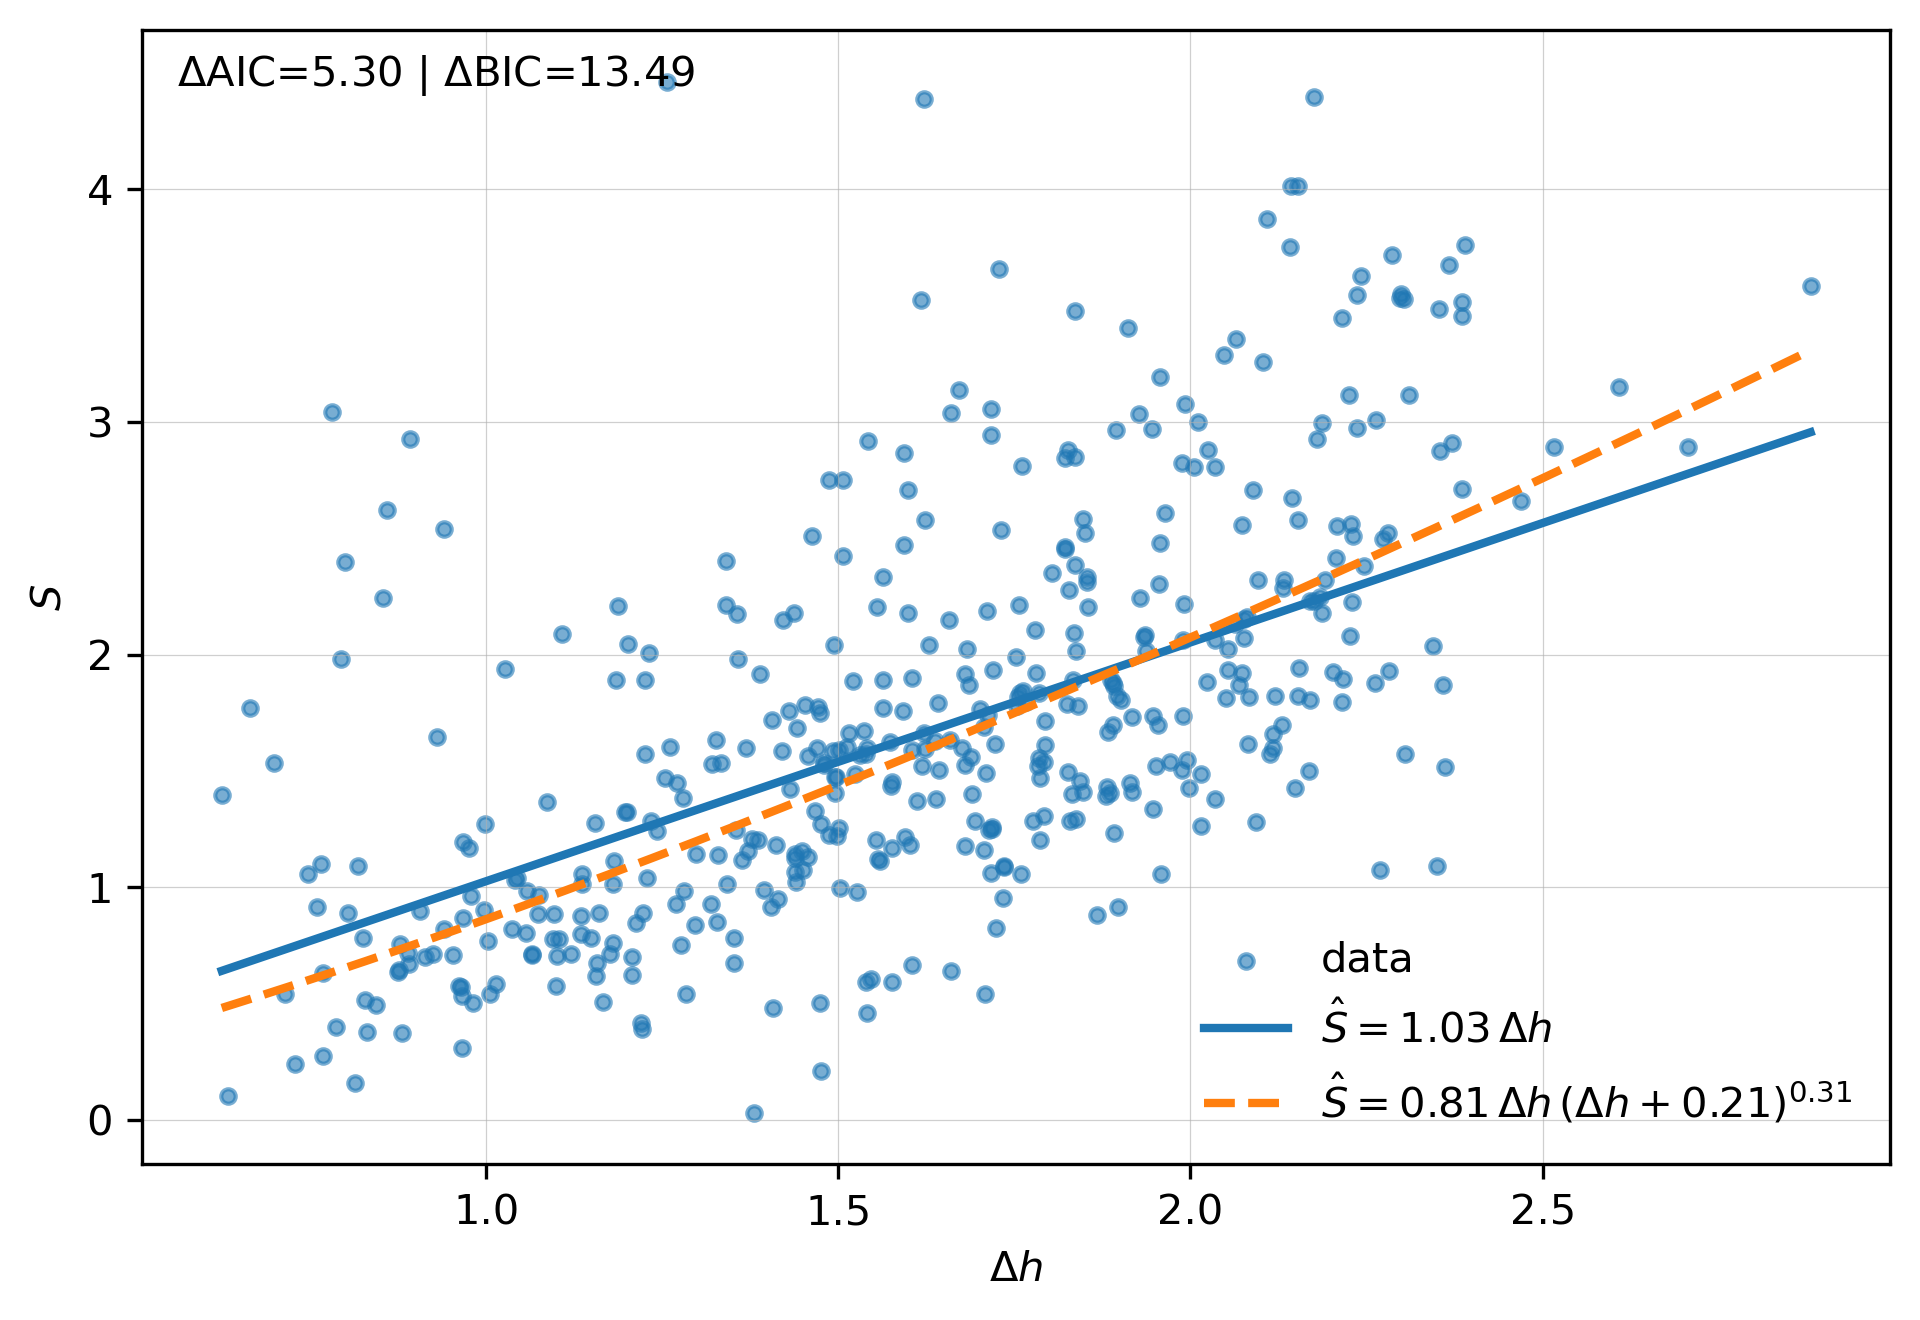

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Safe x-grid for the power model so (Δh + offset) > 0
def _xgrid_power(x_obs, offset, num=400):
    eps = 1e-9
    xmin, xmax = float(np.min(x_obs)), float(np.max(x_obs))
    if np.isfinite(offset):
        xmin = max(xmin, -float(offset) + eps)
    if xmin >= xmax:  # fallback if domain collapses
        xmin = float(np.min(x_obs))
    return np.linspace(xmin, xmax, num=num)

fig, ax = plt.subplots(figsize=(6.5, 4.5))

# Data
ax.scatter(x_all, y_all, s=12, alpha=0.6, label="data")

# Linear curve (use scalar K)
xg_lin = np.linspace(float(np.min(x_all)), float(np.max(x_all)), 400)
ax.plot(
    xg_lin,
    model_linear(K_lin, xg_lin),
    lw=2,
    label=fr"$\hat S = {K_lin:.2f}\,\Delta h$",
)

# Offset–power curve (use scalar K, offset, b)
if np.all(np.isfinite([K_pow, offset_pow, b_pow])):
    xg_pow = _xgrid_power(x_all, offset_pow, num=400)
    ax.plot(
        xg_pow,
        model_power_offset(K_pow, offset_pow, b_pow, xg_pow),
        lw=2,
        linestyle="--",
        label=fr"$\hat S = {K_pow:.2f}\,\Delta h\,(\Delta h {offset_pow:+.2f})^{{{b_pow:.2f}}}$",
    )

# Optional ΔAIC/ΔBIC annotation if those variables are defined
try:
    ax.text(
        0.02, 0.98,
        fr"$\Delta$AIC={dAIC_pooled:.2f} | $\Delta$BIC={dBIC_pooled:.2f}",
        transform=ax.transAxes, va="top", ha="left"
    )
except NameError:
    pass

ax.set_xlabel(r"$\Delta h$")
ax.set_ylabel(r"$S$")
ax.grid(True, linewidth=0.3, alpha=0.6)
ax.legend(frameon=False, loc="best")
plt.tight_layout()
plt.show()
